# Does paying more lead to higher satisfaction?

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import  LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", None)

plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme(style="whitegrid")


reviews = pd.read_csv(
    "/Users/gabrielaslomiany/PycharmProjects/Sephora/data/processed/cleaned_reviews.csv",
    engine="python"
)

product = pd.read_csv(
    "/Users/gabrielaslomiany/PycharmProjects/Sephora/data/processed/cleaned_product_info.csv",
    engine="python"
)

In [2]:
reviews.columns

Index(['author_id', 'rating', 'helpfulness', 'total_pos_feedback_count',
       'submission_time', 'review_text', 'review_title', 'skin_tone',
       'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name',
       'brand_name', 'price_usd'],
      dtype='object')

In [3]:
product.columns

Index(['product_id', 'product_name', 'brand_id', 'brand_name', 'loves_count',
       'rating', 'reviews', 'size', 'ingredients', 'price_usd',
       'limited_edition', 'new', 'online_only', 'out_of_stock',
       'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

In [4]:
df = pd.merge(reviews, product, on="product_id", how="inner")
# df.head()
df.columns

Index(['author_id', 'rating_x', 'helpfulness', 'total_pos_feedback_count',
       'submission_time', 'review_text', 'review_title', 'skin_tone',
       'eye_color', 'skin_type', 'hair_color', 'product_id', 'product_name_x',
       'brand_name_x', 'price_usd_x', 'product_name_y', 'brand_id',
       'brand_name_y', 'loves_count', 'rating_y', 'reviews', 'size',
       'ingredients', 'price_usd_y', 'limited_edition', 'new', 'online_only',
       'out_of_stock', 'sephora_exclusive', 'highlights', 'primary_category',
       'secondary_category', 'tertiary_category', 'child_count'],
      dtype='object')

In [5]:
df.dtypes

author_id                    object
rating_x                     object
helpfulness                  object
total_pos_feedback_count     object
submission_time              object
review_text                  object
review_title                 object
skin_tone                    object
eye_color                    object
skin_type                    object
hair_color                   object
product_id                   object
product_name_x               object
brand_name_x                 object
price_usd_x                 float64
product_name_y               object
brand_id                      int64
brand_name_y                 object
loves_count                   int64
rating_y                    float64
reviews                     float64
size                         object
ingredients                  object
price_usd_y                 float64
limited_edition                bool
new                            bool
online_only                    bool
out_of_stock                

### Checking relationship between price payed for product and high rating
Columns to keep:

In [6]:
df = df[['rating_x', 'price_usd_x', 'loves_count']]
df.head()

,rating_x,price_usd_x,loves_count
0,2,39.0,282865
1,5,39.0,282865
2,5,39.0,282865
3,1,39.0,282865
4,1,39.0,282865


In [7]:
df.dtypes

rating_x        object
price_usd_x    float64
loves_count      int64
dtype: object

In [8]:
df['rating_x'].unique()

array(['2', '5', '1', '3', '4'], dtype=object)

In [9]:
df['rating_x'] = df['rating_x'].str.replace(',', '').astype(int)

In [10]:
df.dtypes

rating_x         int64
price_usd_x    float64
loves_count      int64
dtype: object

In [11]:
df.isna().sum()

rating_x       0
price_usd_x    0
loves_count    0
dtype: int64

### Linear Regression

In [12]:
X = df[['price_usd_x']]
y = df['rating_x']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [15]:
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.0000


In [16]:
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 1.2988
Root mean squared error: 1.1397


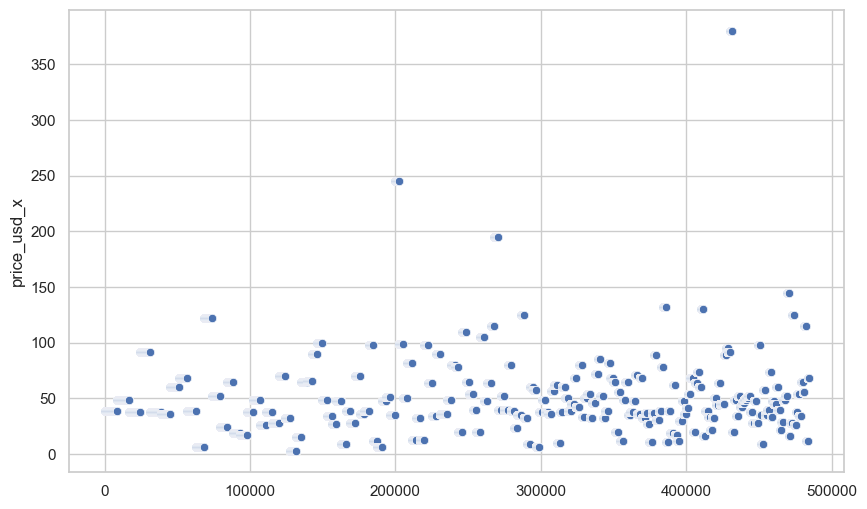

In [20]:
sns.scatterplot(df['price_usd_x'])
plt.show()

### TO BE CONTINUED...